# Model-driven retrieval with PyNNcml: wet/dry, baseline, power law, maps

The physics chain on OpenMRG min/max data: a statistical wet/dry test, two
baseline models, the ITU-R power law, and IDW / GMZ maps.

The concise counterpart of `model_driven_tutorial.ipynb`, kept as the
upstream tutorial. The chain is `src/model_driven.py`, figures `src/plots.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from core import viz_style as vs
import plots

vs.use_style()
from model_driven import ModelDrivenConfig, load, single_link, rain_maps

In [2]:
cfg = ModelDrivenConfig()
link_set = load(slice("2015-06-01", "2015-06-10"))
one = single_link(link_set.get_link(0), cfg)

## Wet/dry

A window is wet when the spread of the attenuation exceeds a threshold
(window 8 samples, threshold 0.1).

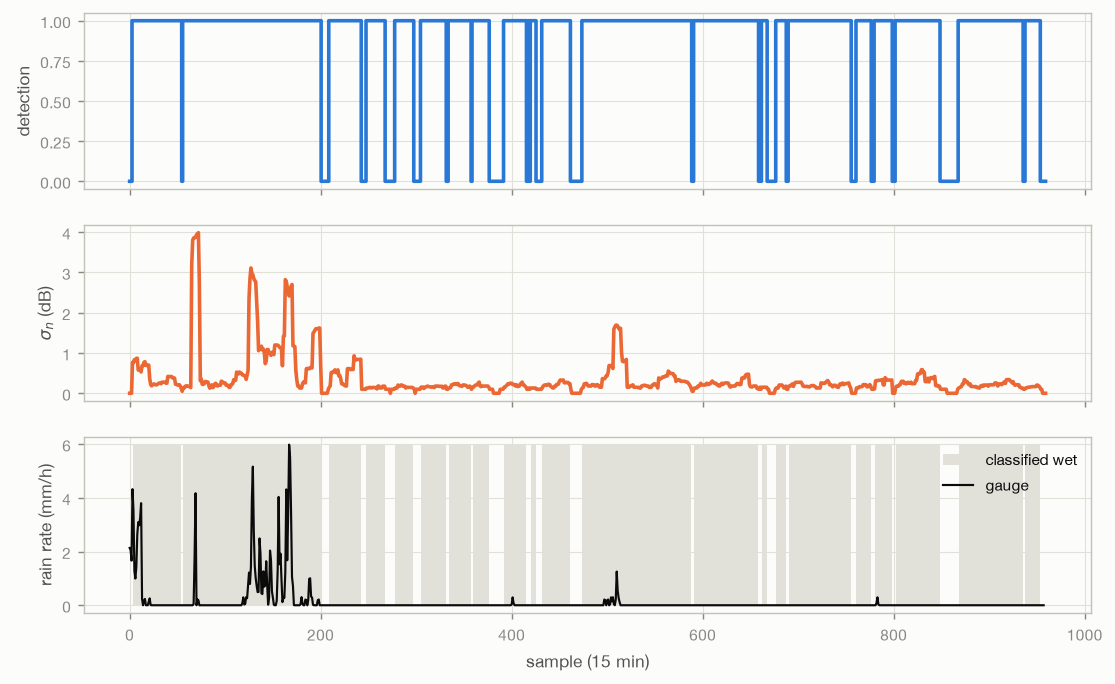

In [3]:
plots.wet_dry_panels(one["detection"], one["sigma"], one["reference"]);

## Baseline and rain

The constant baseline holds the last dry level through a wet spell; the
dynamic one follows the signal. Their difference is the whole estimate.

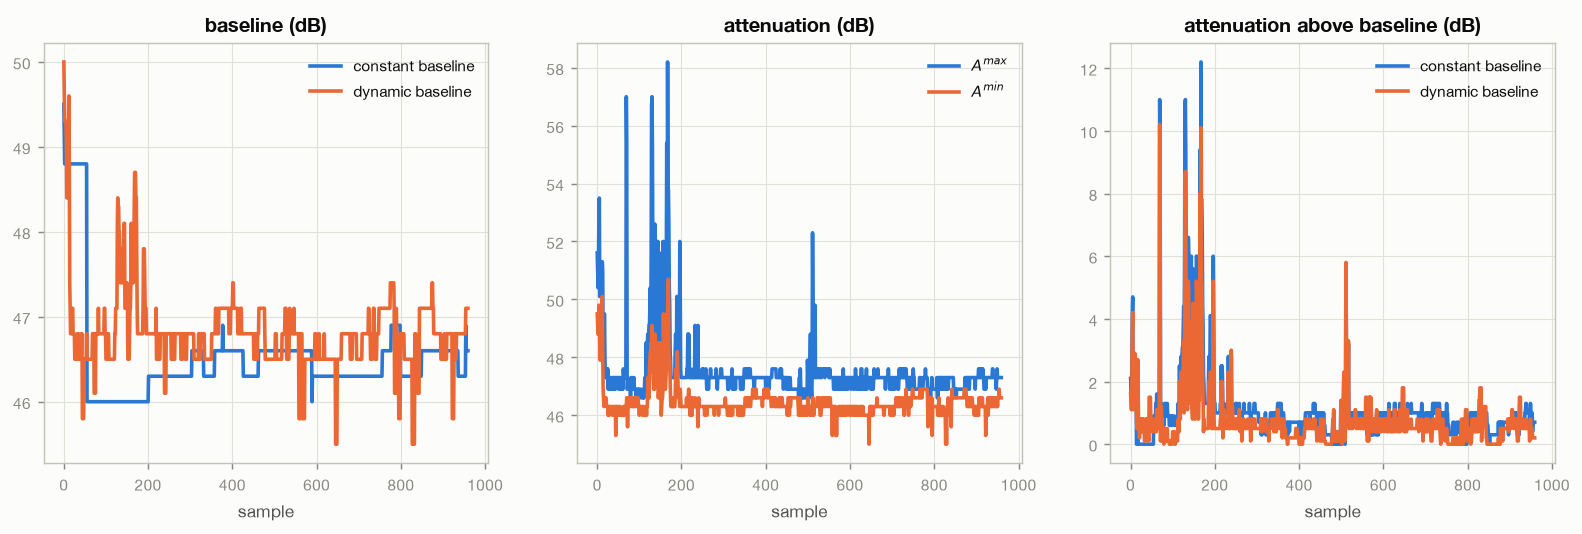

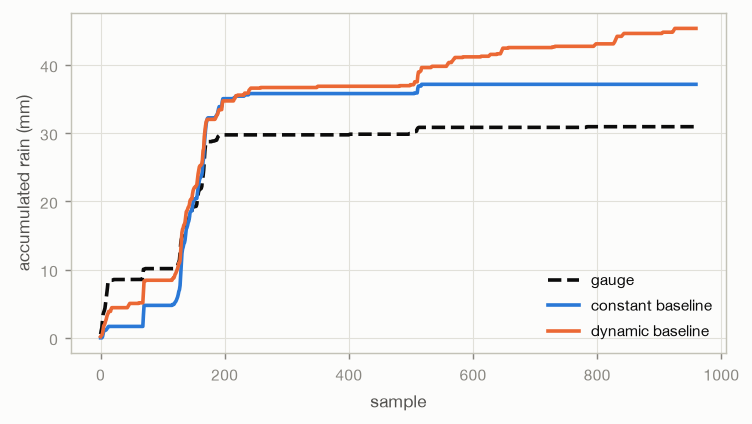

In [4]:
plots.baselines_panels(one["attenuation"], one["baseline"]);
plots.accumulation({"gauge": one["reference"], **one["rain"]});

## Maps

IDW places each link's rain at its midpoint; GMZ fits a field whose line
integrals match the links. Shown at the timestep where IDW varies most.

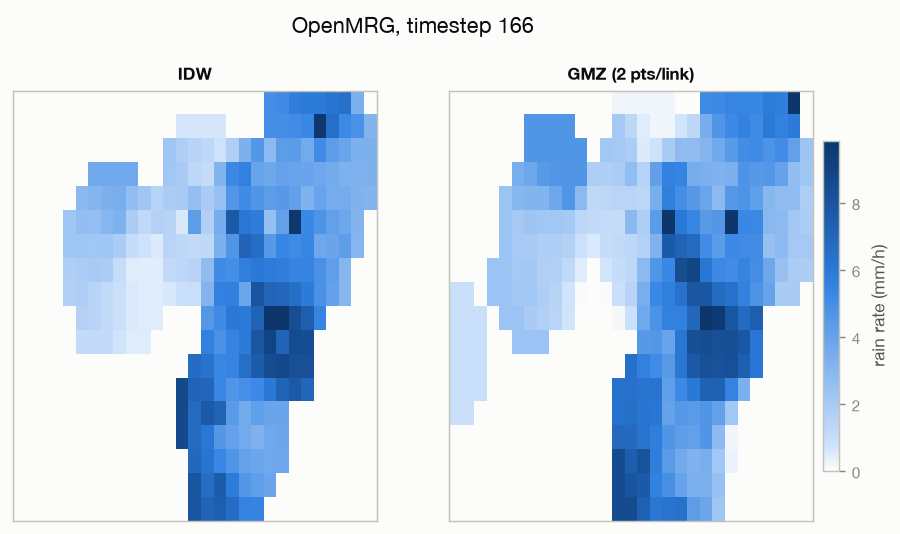

In [5]:
out = rain_maps(link_set, cfg)
plots.map_panels(out["maps"], title=f"OpenMRG, timestep {out['t']}");